# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash

# Day 2: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generate synthetic hourly load data in MW
np.random.seed(15)
raw_load = np.sin(np.linspace(0, 50, 800)) * 50 + 200 + np.random.normal(0, 5, 800)
load_data = raw_load.reshape(-1, 1)

# Task 1: Initialize a MinMaxScaler with feature_range=(-1, 1). Name it 'scaler'.
scaler = MinMaxScaler(feature_range=(-1, 1))

# Task 2: Fit and transform 'load_data' using your scaler. Save it to 'load_scaled'.
load_scaled = scaler.fit_transform(load_data)

# Task 3: Print the shape of 'load_scaled'. It should be (800, 1).
print("Scaled Data Shape:", load_scaled.shape)

Scaled Data Shape: (800, 1)


In [2]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)

# Task 4: Use 'create_sequences' on 'load_scaled' with a sequence length of 12.
# Save the outputs to 'X_np' and 'y_np'.
X_np, y_np = create_sequences(load_scaled, 12)

# Task 5: Convert 'X_np' and 'y_np' to float32 PyTorch tensors named 'X' and 'y'.
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

# Task 6: Print the shape of 'X'. It should be a 3D tensor: [788, 12, 1].
print("Tensor X Shape:", X.shape)

# Time-series Split (No shuffling)
train_size = 600
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

Tensor X Shape: torch.Size([788, 12, 1])


In [3]:
class LoadLSTM(nn.Module):
    def __init__(self):
        super(LoadLSTM, self).__init__()

        # Task 7: Define an nn.LSTM layer.
        # input_size=1, hidden_size=16, batch_first=True. Name it 'self.lstm'.
        self.lstm = nn.LSTM(input_size=1, hidden_size=16, batch_first=True)

        # Task 8: Define an nn.Linear output layer.
        # It takes the hidden_size (16) and outputs 1 value. Name it 'self.linear'.
        self.linear = nn.Linear(16, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        # Task 9: Extract the last time step from lstm_out.
        # Hint: lstm_out[:, -1, :]
        last_step = lstm_out[:, -1, :]

        predictions = self.linear(last_step)
        return predictions

model = LoadLSTM()

In [4]:
# Task 10: Define the MSELoss criterion
criterion = nn.MSELoss()

# Task 11: Initialize the Adam optimizer with model.parameters() and lr=0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 40
for epoch in range(epochs):
    model.train()

    # Task 12: Write the three steps for backpropagation (zero gradients, backward pass, optimizer step).
    # You must also compute the forward pass and loss first.
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.0589
Epoch 20, Loss: 0.0416
Epoch 30, Loss: 0.0245
Epoch 40, Loss: 0.0160


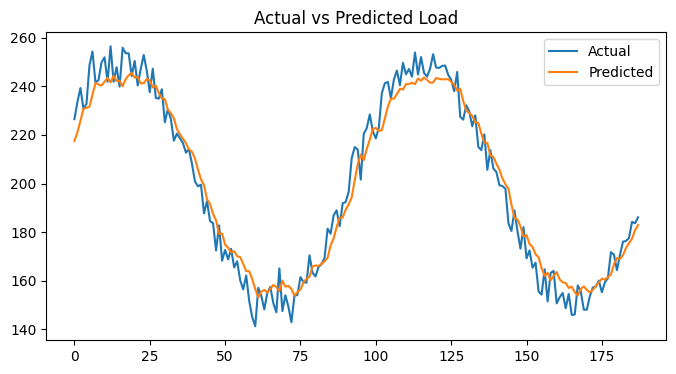

In [5]:
# Task 13: Set the model to evaluation mode
model.eval()

with torch.no_grad():
    # Task 14: Predict using X_test and save to 'test_preds'. Convert the result to a numpy array using .numpy()
    test_preds = model(X_test).numpy()

# Inverse transform to MW values
preds_mw = scaler.inverse_transform(test_preds)
actual_mw = scaler.inverse_transform(y_test.numpy())

# Task 15: Create a plot comparing 'actual_mw' and 'preds_mw'. Add a title and legend.
plt.figure(figsize=(8, 4))
plt.plot(actual_mw, label="Actual") # plot actual
plt.plot(preds_mw, label="Predicted") # plot predicted
plt.title("Actual vs Predicted Load") # title
plt.legend() # legend
plt.show()